In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from keras.optimizers import RMSprop
from keras.callbacks import Callback
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Loading the Dataset and Visualizing the Humidity Time Series

In this section, we load the training and test datasets from  
`DailyDelhiClimateTrain.csv` and `DailyDelhiClimateTest.csv`.

We extract the **humidity** column as the target variable for our RNN model.  
A time-series plot is generated to inspect trend, seasonal behavior,
and potential noise in the data.


In [30]:
# Load training data
train_df = pd.read_csv("Datasets/DailyDelhiClimateTrain.csv")
train_df['date'] = pd.to_datetime(train_df['date'])
train_df.set_index('date', inplace=True)

In [31]:
# Load test data
test_df = pd.read_csv("Datasets/DailyDelhiClimateTest.csv")
test_df['date'] = pd.to_datetime(test_df['date'])
test_df.set_index('date', inplace=True)

In [ ]:
# Extract humidity values
train = train_df['humidity'].values.reshape(-1,1)
test  = test_df['humidity'].values.reshape(-1,1)
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (1462, 1)
Test shape : (114, 1)


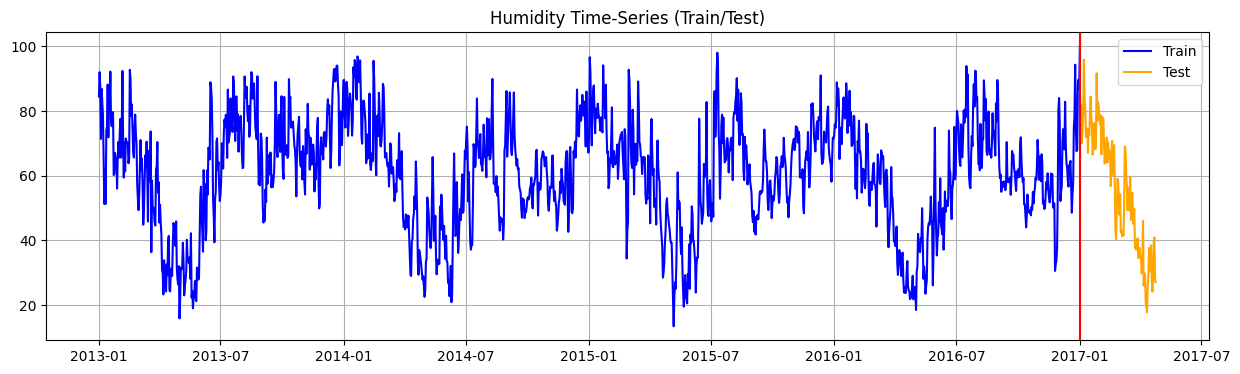

In [ ]:
# Plot humidity time series
plt.figure(figsize=(15,4))
plt.plot(train_df.index, train, c='blue')
plt.plot(test_df.index,  test,  c='orange')
plt.axvline(test_df.index[0], c="red")
plt.legend(["Train", "Test"])
plt.title("Humidity Time-Series (Train/Test)")
plt.grid(True)
plt.show()

## Preparing Data for the RNN (Embedding / Step Size)

RNN models require sequences as input.  
We choose a window size (`step = 4`), meaning the model will take **4 previous values**
to predict the next one.

To generate sliding windows, we create an extended version of each dataset
and convert them into supervised (X, Y) matrices.


In [ ]:
# Extend the sequences by repeating the last value
step = 4
train_ext = np.append(train, np.repeat(train[-1], step))
test_ext  = np.append(test,  np.repeat(test[-1], step))


In [ ]:
# Convert to supervised learning format
def convertToMatrix(data, step):
    X, Y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step])
        Y.append(data[i+step])
    return np.array(X), np.array(Y)

trainX, trainY = convertToMatrix(train_ext, step)
testX,  testY  = convertToMatrix(test_ext,  step)
trainX = trainX.reshape(trainX.shape[0], 1, trainX.shape[1])
testX  = testX.reshape(testX.shape[0],  1, testX.shape[1])
print(trainX.shape, trainY.shape)
print(testX.shape,  testY.shape)

(1462, 1, 4) (1462,)
(114, 1, 4) (114,)


## Building the SimpleRNN Model

We construct a simple RNN architecture with:
- 128 RNN units  
- 32-unit dense layer  
- 1-unit output layer  
- ReLU activation  
- RMSprop optimizer  

This model learns the temporal patterns in humidity data.


In [ ]:
# Build Simple RNN Model
def build_simple_rnn(num_units=128, embedding=4, num_dense=32, lr=0.001):
    model = Sequential()
    model.add(SimpleRNN(num_units, input_shape=(1, embedding), activation="relu"))
    model.add(Dense(num_dense, activation="relu"))
    model.add(Dense(1))
    model.compile(loss="mean_squared_error",
                  optimizer=RMSprop(learning_rate=lr),
                  metrics=["mse"])
    return model

model = build_simple_rnn(embedding=step)
model.summary()

/Users/z132987/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,185 (82.75 KB)

 Trainable params: 21,185 (82.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training the RNN Model

We train the model for **500 epochs** with a batch size of **16**.

A callback prints a message every 50 epochs for monitoring.


In [ ]:
# Custom Callback to print epoch info
class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1} completed")

In [ ]:
# Training the model
batch_size = 16
num_epochs = 500

history = model.fit(
    trainX, trainY,
    epochs=num_epochs,
    batch_size=batch_size,
    callbacks=[MyCallback()],
    verbose=0
)

Epoch 50 completed
Epoch 100 completed
Epoch 150 completed
Epoch 200 completed
Epoch 250 completed
Epoch 300 completed
Epoch 350 completed
Epoch 400 completed
Epoch 450 completed
Epoch 500 completed


## Visualizing Training Loss (RMSE)

The RMSE loss curve shows a rapid decrease during the first 20–30 epochs, followed by a gradual stabilization.
By around epoch 100, the model converges to an RMSE close to 8, and remains stable until epoch 500.
This indicates that the RNN successfully learned the temporal patterns in humidity without signs of severe overfitting.
The initial spike in RMSE is normal as weights are randomly initialized.


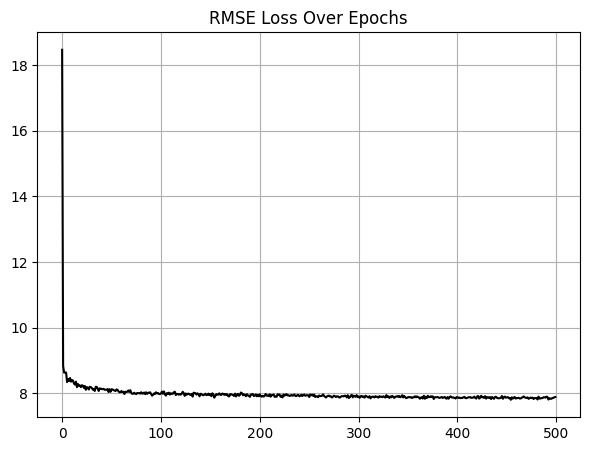

In [ ]:
# Plot RMSE Loss over epochs
plt.figure(figsize=(7,5))
plt.plot(np.sqrt(history.history['loss']), c='k')
plt.title("RMSE Loss Over Epochs")
plt.grid(True)
plt.show()

## Generating Predictions on Train and Test Sets
In the combined plot, the model captures the overall seasonal trend of humidity, particularly the peaks and troughs visible in the training set.
When extended to the test set, the predicted curve:

- Follows the general downward trend at the start of 2017

- Recreates short-term variability reasonably well

- Shows slightly smoother behavior compared to the true series

The red vertical line clearly marks the train/test boundary.
The predictions do not diverge significantly, showing the model’s ability to generalize to unseen data.


In [ ]:
# Make predictions
trainPredict = model.predict(trainX)
testPredict  = model.predict(testX)

predicted = np.concatenate((trainPredict, testPredict))


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


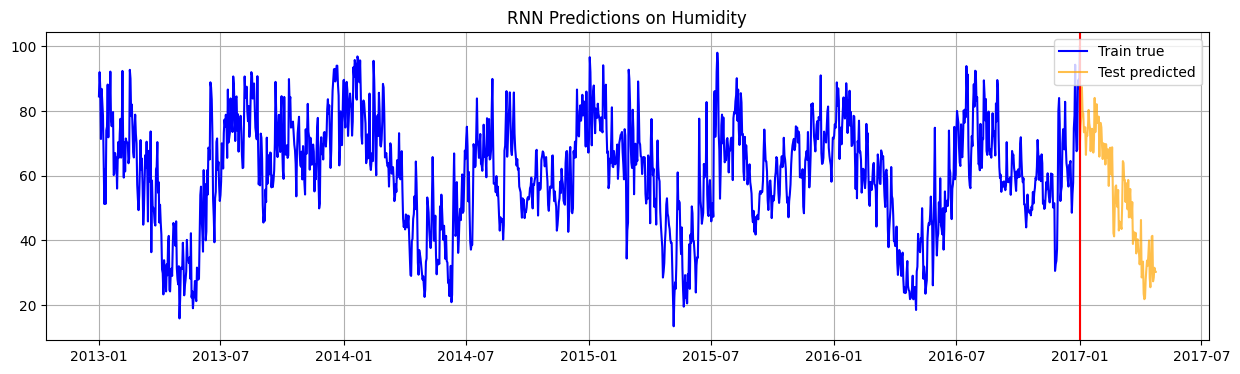

In [ ]:
# Plot predictions
plt.figure(figsize=(15,4))
plt.plot(train_df.index, train, c='blue')
plt.plot(test_df.index,  predicted[-len(test_df):], c='orange', alpha=0.7)
plt.axvline(test_df.index[0], c='red')
plt.legend(["Train true", "Test predicted"])
plt.grid(True)
plt.title("RNN Predictions on Humidity")
plt.show()


## Test-Set Comparison (Actual vs Predicted)
When plotting actual vs predicted humidity on the test set only, the two lines remain close and parallel, showing good alignment.
Key observations:

- Peaks and dips are captured, but the model tends to underestimate extreme highs and overestimate extreme lows, suggesting mild regression to the mean.

- The day-to-day fluctuations are followed with reasonable accuracy.

- No noticeable systematic drift is observed across the prediction horizon.

This agrees with the moderate but stable RMSE seen during training.

In [ ]:
# Evaluate model performance
y_true = test.reshape(-1)
y_pred = testPredict.reshape(-1)

mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

print("Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


Evaluation Metrics:
MAE  : 6.5737
RMSE : 8.6691


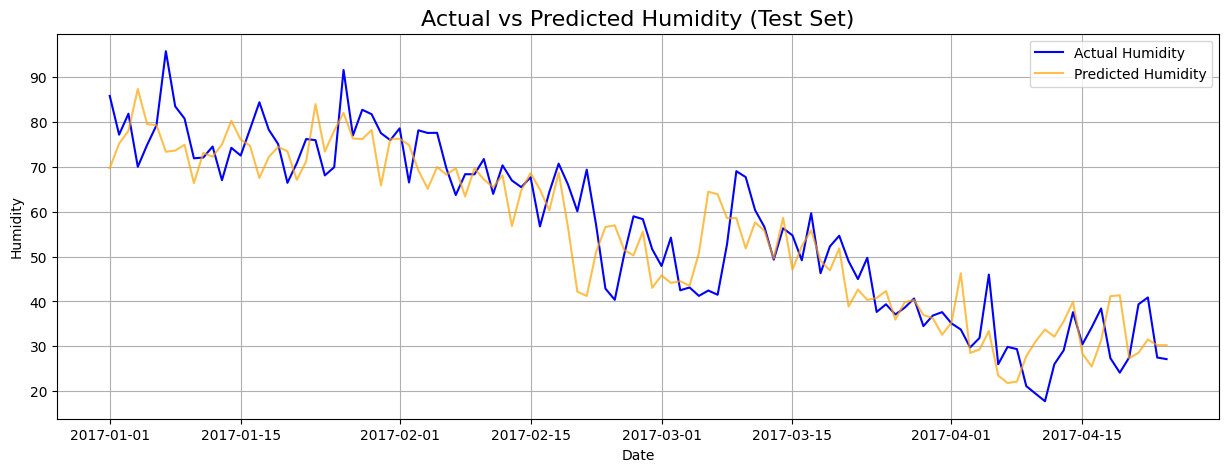

In [ ]:
# Plot actual vs predicted humidity
plt.figure(figsize=(15,5))
plt.plot(test_df.index, y_true, label="Actual Humidity", color='blue')
plt.plot(test_df.index, y_pred, label="Predicted Humidity", color='orange', alpha=0.7)
plt.title("Actual vs Predicted Humidity (Test Set)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True)
plt.show()


## Residuals

# The histogram of residuals is approximately centered around zero, showing:

- A symmetric distribution

- No heavy skew

- No problematic long tail on one side

This pattern suggests that prediction errors are mostly random rather than systematic.

The spread of residuals is consistent with the RMSE value of ~8.7.


# Plotting the residuals chronologically shows:

- Fluctuations around zero

- No clear temporal trend

- Occasional spikes representing isolated prediction errors

- No evidence of model drift or structural break

This confirms that the RNN’s performance remains stable across the entire test period.

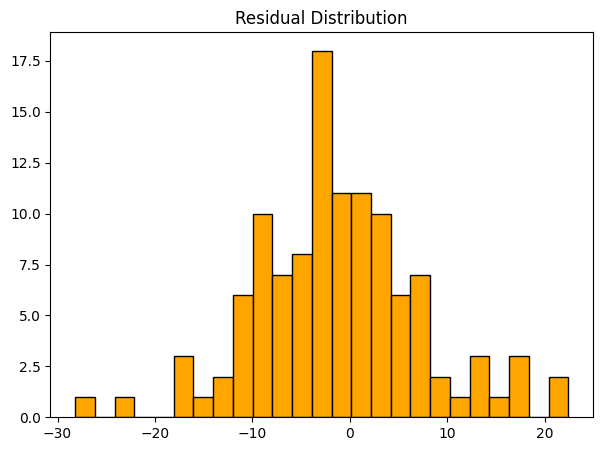

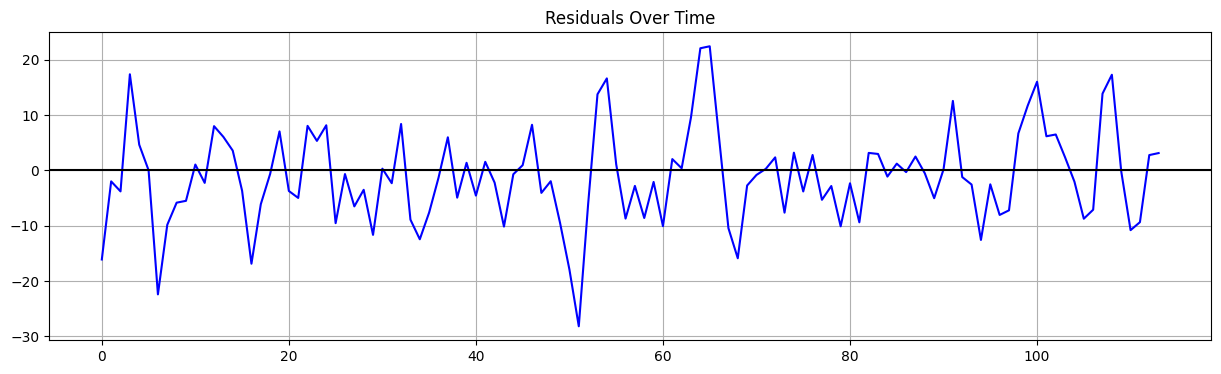

In [ ]:
# Plot residuals
residuals = testPredict.reshape(-1) - test.reshape(-1)

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=25, edgecolor='k', color='orange')
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(15,4))
plt.plot(residuals, c='blue')
plt.axhline(0, color='black')
plt.grid(True)
plt.title("Residuals Over Time")
plt.show()
